<a href="https://colab.research.google.com/github/mekhyal/ML-based-for-detecting-money-laundring-using-SAML-D/blob/main/MoneyLaundringDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLD\/AML**

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from scipy import sparse
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

# **1. Dataset Confirmation**
## 1.1
- Dataset: Anti Money Laundering Transaction Data (SAML-D)
- Source: we found this dataset in kaggle,
- URL: https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml
------------------------------------------------
## 1.2
After completing the preprocessing stage (P2), the cleaned dataset contained approximately 9.5 million records with 37 attributes. For the modeling phase (P3), a 10% stratified sample of the dataset was used, resulting in 950,485 records, while preserving the same 37 attributes.


---
## 1.3
In the preprocessing phase (P2), the raw AML transaction dataset was cleaned and transformed into a model-ready format. Inconsistent categorical values were standardized through normalization and grouping, and high-cardinality categorical attributes such as payment type, currency, bank location, and laundering patterns were consolidated and one-hot encoded. The transaction amount was log-transformed to reduce skewness and scaled to improve numerical stability. Irrelevant or redundant fields were removed, missing or noisy values were handled, and the final dataset was converted into a fully numeric representation suitable for classification, clustering, and regression tasks.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
OUTPUT_PATH = '/content/'

# Load processed feature matrices
X_train = sparse.load_npz(f'{OUTPUT_PATH}/X_train_processed.npz')
X_val   = sparse.load_npz(f'{OUTPUT_PATH}/X_val_processed.npz')
X_test  = sparse.load_npz(f'{OUTPUT_PATH}/X_test_processed.npz')

# Load labels
y_train = pd.read_csv(f'{OUTPUT_PATH}/y_train.csv').squeeze("columns")
y_val   = pd.read_csv(f'{OUTPUT_PATH}/y_val.csv').squeeze("columns")
y_test  = pd.read_csv(f'{OUTPUT_PATH}/y_test.csv').squeeze("columns")

# Optional metadata
preprocessor = joblib.load(f'{OUTPUT_PATH}/preprocessor.pkl')

with open(f'{OUTPUT_PATH}/feature_names.json', 'r') as f:
    feature_names = json.load(f)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:  ", X_val.shape, y_val.shape)
print("Test shape: ", X_test.shape, y_test.shape)
print("Classification data loaded successfully.")

Train shape: (6653396, 30) (6653396,)
Val shape:   (1425728, 30) (1425728,)
Test shape:  (1425728, 30) (1425728,)
Classification data loaded successfully.


In [ ]:
fraud = df[df.Is_laundering == 1]
non_fraud = df[df.Is_laundering == 0]

NameError: name 'df' is not defined

In [ ]:
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_val distribution:")
print(y_val.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

y_train distribution:
Is_laundering
0    0.998961
1    0.001039
Name: proportion, dtype: float64

y_val distribution:
Is_laundering
0    0.998961
1    0.001039
Name: proportion, dtype: float64

y_test distribution:
Is_laundering
0    0.998961
1    0.001039
Name: proportion, dtype: float64


# **2. Classification**

In [ ]:
# def evaluate_model(name, model, X_train, y_train, X_test, y_test, pos_label=1):
#     # GaussianNB does not support sparse matrices directly
#     if model.__class__.__name__ == "GaussianNB":
#         X_train_fit = X_train.toarray() if hasattr(X_train, "toarray") else X_train
#         X_test_eval = X_test.toarray() if hasattr(X_test, "toarray") else X_test
#     else:
#         X_train_fit = X_train
#         X_test_eval = X_test

#     model.fit(X_train_fit, y_train)
#     # Get probabilities
#     y_prob = model.predict_proba(X_test_eval)[:, 1]

#     # Set threshold (you can tune this)
#     threshold = 0.3

#     # Apply threshold
#     y_pred = (y_prob >= threshold).astype(int)

#     acc  = accuracy_score(y_test, y_pred)
#     prec = precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
#     rec  = recall_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
#     f1   = f1_score(y_test, y_pred, pos_label=pos_label, zero_division=0)

#     print(f"\n=== {name} ===")
#     print(f"Accuracy : {acc:.4f}")
#     print(f"Precision: {prec:.4f}")
#     print(f"Recall   : {rec:.4f}")
#     print(f"F1-score : {f1:.4f}\n")

#     print("Classification Report:")
#     print(classification_report(y_test, y_pred, zero_division=0))

#     cm = confusion_matrix(y_test, y_pred)
#     plt.figure(figsize=(5, 4))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.title(f"{name} - Confusion Matrix")
#     plt.tight_layout()
#     plt.show()

#     return acc, prec, rec, f1

def evaluate_model(name, model, X_train, y_train, X_test, y_test, pos_label=1, threshold=None):
    # Models that need dense input
    dense_models = ["GaussianNB", "GradientBoostingClassifier"]

    if model.__class__.__name__ in dense_models:
        X_train_fit = X_train.toarray() if hasattr(X_train, "toarray") else X_train
        X_test_eval = X_test.toarray() if hasattr(X_test, "toarray") else X_test
    else:
        X_train_fit = X_train
        X_test_eval = X_test

    # Train
    model.fit(X_train_fit, y_train)

    # Predict
    if threshold is not None and hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_eval)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test_eval)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=pos_label, zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1

In [ ]:
class_names = ['No (0)', 'Yes (1)']


=== Naive Bayes ===
Accuracy : 0.8762
Precision: 0.0038
Recall   : 0.4497
F1-score : 0.0075

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93   1424247
           1       0.00      0.45      0.01      1481

    accuracy                           0.88   1425728
   macro avg       0.50      0.66      0.47   1425728
weighted avg       1.00      0.88      0.93   1425728



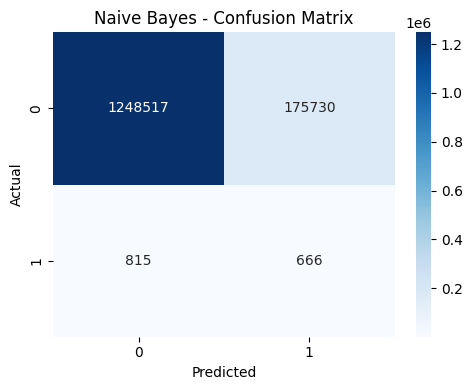

In [ ]:
nb_model = GaussianNB()

metrics_nb = evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train, y_train,
    X_test, y_test
)


=== Decision Tree ===
Accuracy : 0.9983
Precision: 0.1087
Recall   : 0.0824
F1-score : 0.0937

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1424247
           1       0.11      0.08      0.09      1481

    accuracy                           1.00   1425728
   macro avg       0.55      0.54      0.55   1425728
weighted avg       1.00      1.00      1.00   1425728



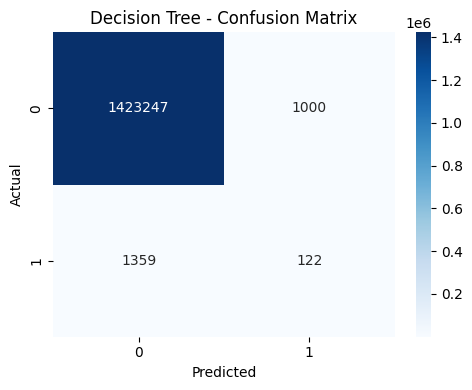

In [ ]:
# dt_model = DecisionTreeClassifier(
#     random_state=42,
#     class_weight="balanced"
# )

# metrics_dt = evaluate_model(
#     "Decision Tree",
#     dt_model,
#     X_train, y_train,
#     X_test, y_test
# )
dt_model = DecisionTreeClassifier(random_state=42)

metrics_dt = evaluate_model(
    "Decision Tree",
    dt_model,
    X_train, y_train,
    X_test, y_test
)


=== Logistic Regression ===
Accuracy : 0.8422
Precision: 0.0041
Recall   : 0.6232
F1-score : 0.0081

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91   1424247
           1       0.00      0.62      0.01      1481

    accuracy                           0.84   1425728
   macro avg       0.50      0.73      0.46   1425728
weighted avg       1.00      0.84      0.91   1425728



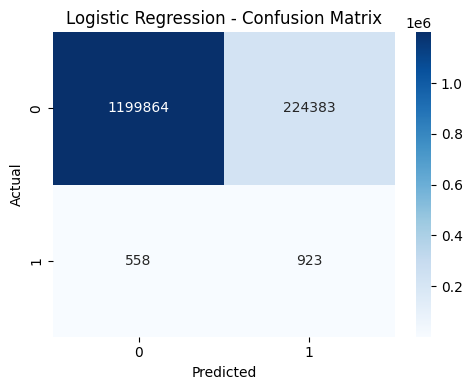

In [ ]:
# lr_model = LogisticRegression(
#     max_iter=2000,
#     class_weight="balanced",
#     random_state=42,
#     n_jobs=-1
# )

# metrics_lr = evaluate_model(
#     "Logistic Regression",
#     lr_model,
#     X_train, y_train,
#     X_test, y_test
# )
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

metrics_lr = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train, y_train,
    X_test, y_test
)


=== Random Forest ===
Accuracy : 0.9983
Precision: 0.1070
Recall   : 0.0817
F1-score : 0.0926

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1424247
           1       0.11      0.08      0.09      1481

    accuracy                           1.00   1425728
   macro avg       0.55      0.54      0.55   1425728
weighted avg       1.00      1.00      1.00   1425728



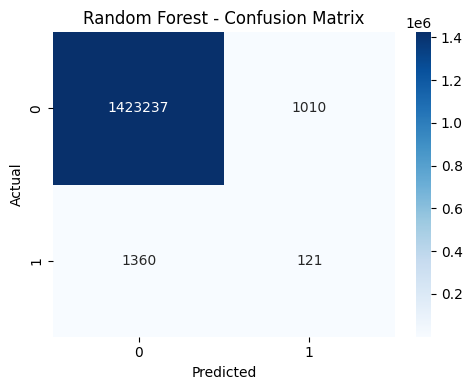

In [ ]:
# rf_model = RandomForestClassifier(
#     n_estimators=200,
#     random_state=42,
#     class_weight="balanced",
#     n_jobs=-1
# )

# metrics_rf = evaluate_model(
#     "Random Forest",
#     rf_model,
#     X_train, y_train,
#     X_test, y_test
# )
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

metrics_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_train, y_train,
    X_test, y_test
)

In [ ]:
# Convert to dense only if needed for SMOTE
X_train_sm_input = X_train.toarray() if hasattr(X_train, "toarray") else X_train

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sm_input, y_train)

print("Original y_train distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE y_train distribution:")
print(y_train_sm.value_counts())

Original y_train distribution:
Is_laundering
0    6646485
1       6911
Name: count, dtype: int64

After SMOTE y_train distribution:
Is_laundering
0    6646485
1    6646485
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [22:19:20] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



=== XGBoost + SMOTE + Threshold ===
Accuracy : 0.3872
Precision: 0.0015
Recall   : 0.8933
F1-score : 0.0030

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.39      0.56   1424247
           1       0.00      0.89      0.00      1481

    accuracy                           0.39   1425728
   macro avg       0.50      0.64      0.28   1425728
weighted avg       1.00      0.39      0.56   1425728



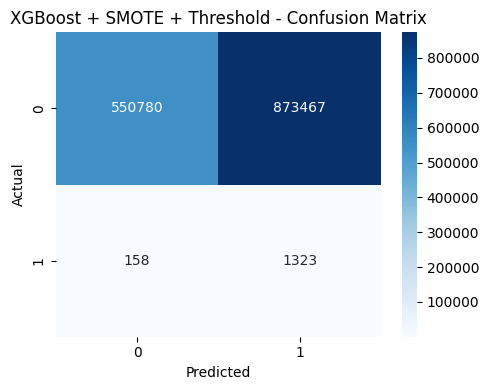

In [ ]:
# from xgboost import XGBClassifier

# neg, pos = (y_train_sm == 0).sum(), (y_train_sm == 1).sum()

# xgb_model = XGBClassifier(
#     objective="binary:logistic",
#     eval_metric="logloss",
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# metrics_xgb = evaluate_model(
#     "XGBoost + SMOTE",
#     xgb_model,
#     X_train_sm, y_train_sm,
#     X_test, y_test
# )
xgb_model = XGBClassifier(
    tree_method='hist',
    device='cuda',
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# X_test stays original, but convert if sparse and training became dense
X_test_for_smote_models = X_test.toarray() if hasattr(X_test, "toarray") else X_test

metrics_xgb = evaluate_model(
    "XGBoost + SMOTE + Threshold",
    xgb_model,
    X_train_sm, y_train_sm,
    X_test_for_smote_models, y_test,
    threshold=0.3
)


=== Gradient Boosting + SMOTE + Threshold ===
Accuracy : 0.3003
Precision: 0.0014
Recall   : 0.9561
F1-score : 0.0028

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.30      0.46   1424247
           1       0.00      0.96      0.00      1481

    accuracy                           0.30   1425728
   macro avg       0.50      0.63      0.23   1425728
weighted avg       1.00      0.30      0.46   1425728



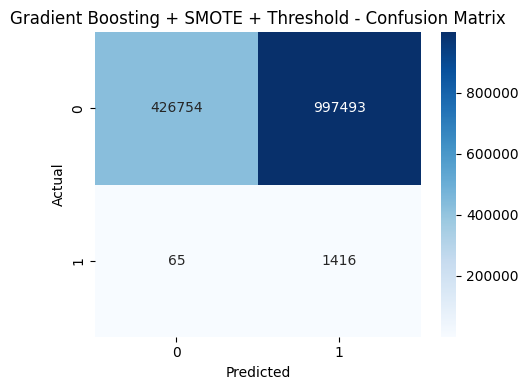

In [ ]:
# from sklearn.ensemble import GradientBoostingClassifier

# gb_model = GradientBoostingClassifier(
#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=3,
#     random_state=42
# )

# metrics_gb = evaluate_model(
#     "Gradient Boosting + SMOTE",
#     gb_model,
#     X_train_sm, y_train_sm,
#     X_test, y_test
# )
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

metrics_gb = evaluate_model(
    "Gradient Boosting + SMOTE + Threshold",
    gb_model,
    X_train_sm, y_train_sm,
    X_test_for_smote_models, y_test,
    threshold=0.3
)

In [ ]:
results_df = pd.DataFrame({
    "Model": [
        "k-Nearest Neighbors",
        "Naive Bayes",
        "Decision Tree",
        "Logistic Regression",
        "Random Forest",
        "XGBoost + SMOTE + Threshold",
        "Gradient Boosting + SMOTE + Threshold"
    ],
    "Accuracy": [
        metrics_knn[0],
        metrics_nb[0],
        metrics_dt[0],
        metrics_lr[0],
        metrics_rf[0],
        metrics_xgb[0],
        metrics_gb[0]
    ],
    "Precision": [
        metrics_knn[1],
        metrics_nb[1],
        metrics_dt[1],
        metrics_lr[1],
        metrics_rf[1],
        metrics_xgb[1],
        metrics_gb[1]
    ],
    "Recall": [
        metrics_knn[2],
        metrics_nb[2],
        metrics_dt[2],
        metrics_lr[2],
        metrics_rf[2],
        metrics_xgb[2],
        metrics_gb[2]
    ],
    "F1-score": [
        metrics_knn[3],
        metrics_nb[3],
        metrics_dt[3],
        metrics_lr[3],
        metrics_rf[3],
        metrics_xgb[3],
        metrics_gb[3]
    ]
})

results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)
results_df

# **3. Clustering**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Base clustering dataframe (no labels inside)
df_cluster = (
    df_Clustering
    .drop(columns=["Is_laundering"])
    .fillna(0)
    .copy()
)


# Clean clustering dataframe (no labels, no suspicious rules)
suspicious_cols = [
    "Laundering_type_grouped_suspicious_invoice",
    "Laundering_type_grouped_suspicious_large",
    "Laundering_type_grouped_suspicious_structuring"
]

df_cluster_clean = (
    df_Clustering
    .drop(columns=["Is_laundering"] + suspicious_cols)
    .fillna(0)
    .copy()
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

scaler_clean = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(df_cluster_clean)



In [ ]:
import os
os.makedirs("figures", exist_ok=True)



For clustering, we apply unsupervised learning techniques that do not use class labels. Therefore, the target variable `Is_laundering` was removed before applying any clustering algorithm.

Two versions of the dataset were prepared:
1. **Full Feature Set**: All features except `Is_laundering`.
2. **Clean Feature Set**: In addition to removing `Is_laundering`, rule-based suspicious indicators ( suspicious structuring and large transaction flags) were also removed to avoid injecting prior expert knowledge into the clustering process.

Missing values were handled by replacing them with zeros, and all features were standardized using `StandardScaler` to ensure equal contribution during distance-based clustering.


In [ ]:
inertias = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(alpha=0.3)
plt.savefig("figures/fig_elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()



- Elbow Method for Selecting k

The Elbow Method was used to determine the optimal number of clusters for k-Means. This method evaluates the within-cluster sum of squares (inertia) for different values of k. As k increases, inertia decreases; however, beyond a certain point, the improvement becomes marginal.

From the plot below, a noticeable bend appears around **k = 6–7**, indicating diminishing returns for higher values of k. Based on this observation, k = 6 was selected as a reasonable balance between model complexity and cluster compactness.


In [ ]:
sil_scores = []
k_range = range(2, 11)

n_samples = X_scaled.shape[0]
sample_size = min(10_000, n_samples)
rng = np.random.default_rng(42)
sample_idx = rng.choice(n_samples, size=sample_size, replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels_tmp = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled[sample_idx], labels_tmp[sample_idx])
    sil_scores.append(score)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (Sampled Data)")
plt.grid(alpha=0.3)
plt.savefig("figures/fig_silhouette_method.png", dpi=300, bbox_inches="tight")
plt.show()



Silhouette Score Analysis

To further validate the choice of k, the Silhouette Score was computed on a randomly sampled subset of the data due to dataset size. The silhouette score measures how well-separated and cohesive the clusters are, with higher values indicating better-defined clusters.

The silhouette analysis shows that while k = 2 yields the highest score, such a small number of clusters would oversimplify the transaction behaviors. Among higher values, **k = 6 provides a reasonable silhouette score while allowing for more granular behavioral segmentation**, making it suitable for exploratory analysis.


In [ ]:
k = 6

# Base clustering
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df_with_clusters = df_cluster.copy()
df_with_clusters["cluster"] = labels

# Clean clustering
kmeans_clean = KMeans(n_clusters=k, random_state=42)
labels_clean = kmeans_clean.fit_predict(X_clean_scaled)

df_with_clusters_clean = df_cluster_clean.copy()
df_with_clusters_clean["cluster_clean"] = labels_clean



- Final Selection of Number of Clusters

Although k = 2 achieves the highest silhouette score, it produces overly broad clusters that do not capture the diversity of transaction behaviors. Therefore, **k = 6 was selected** as the final number of clusters, as it balances interpretability, behavioral granularity, and clustering quality. This choice is supported by both the elbow method and silhouette analysis.

- Methodological Consideration

The clean clustering configuration, which excludes rule-based suspicious indicators, was selected for interpretation. This ensures that the clustering process remains purely unsupervised and is not biased by predefined laundering heuristics. As a result, the discovered clusters represent naturally emerging transaction behavior patterns rather than pre-labeled risk categories.


The resulting clusters were further analyzed using visualization techniques and behavioral summaries to interpret the underlying transaction patterns and assess their relationship with money laundering activity.
---


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, alpha=0.6, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Visualization using PCA (With Rule-Based Features)")
plt.colorbar(label="Cluster ID")
plt.savefig("figures/fig_pca_with_rule_based.png", dpi=300, bbox_inches="tight")
plt.show()





In [ ]:
pca_clean = PCA(n_components=2)
X_pca_clean = pca_clean.fit_transform(X_clean_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_clean[:,0], X_pca_clean[:,1], c=labels_clean, alpha=0.6, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Visualization using PCA (Clean Clustering)")
plt.colorbar(label="Cluster ID")
plt.savefig("figures/fig_pca_clean.png", dpi=300, bbox_inches="tight")
plt.show()



- Cluster Visualization Using PCA

The PCA visualization shows that clustering with rule-based suspicious features produces more compact and visually separated clusters. However, this separation is largely driven by features that already encode expert knowledge about suspicious behavior. In contrast, the clean clustering configuration results in more nuanced cluster structure, reflecting naturally emerging transaction patterns without prior assumptions. Although the clean clusters appear less sharply separated, they provide a more realistic representation of transaction behavior and are therefore more appropriate for unsupervised pattern discovery.



In [ ]:
y_jitter = (
    df_cluster_clean["Payment_type_cash withdrawal"]
    + np.random.uniform(-0.03, 0.03, size=len(df_cluster_clean))
)

plt.figure(figsize=(9,6))
scatter = plt.scatter(
    df_cluster_clean["Amount_log_scaled"],
    y_jitter,
    c=labels_clean,
    cmap="tab10",
    alpha=0.6,
    s=12
)

plt.xlabel("Log-Scaled Transaction Amount")
plt.ylabel("Cash Withdrawal Indicator (jittered)")
plt.yticks([0,1], ["No Cash Withdrawal", "Cash Withdrawal"])
plt.title("2D Cluster Visualization (Clean Clustering)")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(alpha=0.3)
plt.savefig("figures/fig_2d_clean.png", dpi=300, bbox_inches="tight")
plt.show()


**2D Cluster Visualization Using Log-Scaled Amount and Cash Withdrawal (Clean Clustering)**

This figure visualizes the clustering results using two original features: the log-scaled transaction amount and the cash withdrawal indicator. Since the cash withdrawal variable is binary, a small amount of jitter was added solely to improve visualization clarity and does not affect the clustering process.

The plot shows substantial overlap between clusters in this two-dimensional space, indicating that transaction amount and cash withdrawal behavior alone are insufficient to fully separate the clusters. This supports the need for higher-dimensional analysis and motivates the use of PCA to better understand the clustering structure.


In [ ]:
y_jitter = df_cluster["Payment_type_cash withdrawal"] + \
           np.random.uniform(-0.03, 0.03, size=len(df_cluster))

plt.figure(figsize=(9,6))
scatter = plt.scatter(
    df_cluster["Amount_log_scaled"],
    y_jitter,
    c=labels,
    cmap="tab10",
    alpha=0.6,
    s=12
)

plt.xlabel("Log-Scaled Transaction Amount")
plt.ylabel("Cash Withdrawal Indicator (jittered)")
plt.title("2D Cluster Visualization (With Rule-Based Features)")
plt.yticks([0, 1], ["No Cash Withdrawal", "Cash Withdrawal"])

plt.colorbar(scatter, label="Cluster ID")
plt.grid(alpha=0.3)
plt.show()


**2D Cluster Visualization Using Log-Scaled Amount and Cash Withdrawal (With Rule-Based Features)**

This figure presents the same two-dimensional visualization after including rule-based laundering indicators in the clustering process. Compared to the clean clustering, clusters appear more concentrated and less overlapping, suggesting that rule-based features strongly influence cluster formation.

While this results in clearer separation, it also indicates that prior human-defined rules may dominate the clustering structure. This comparison highlights the impact of rule-based features and justifies analyzing both clean and rule-informed clustering outcomes.


In [ ]:
cluster_summary = (
    df_with_clusters
    .join(df_Clustering["Is_laundering"])
    .groupby("cluster")
    .agg(
        count=("Is_laundering", "count"),
        laundering_rate=("Is_laundering", "mean"),
        avg_amount=("Amount_log_scaled", "mean"),
        cash_withdrawal_rate=("Payment_type_cash withdrawal", "mean"),
        cross_border_rate=("Payment_type_cross border", "mean")
    )
)

cluster_summary




**Cluster Characteristics (With Rule-Based Features)**  
This table summarizes the size and key behavioral statistics of each cluster obtained using all available transactional features (excluding the target label). The laundering rate is used only for post-clustering interpretation.


In [ ]:
summary_clean = (
    df_with_clusters_clean
    .join(df_Clustering["Is_laundering"])
    .groupby("cluster_clean")
    .agg(
        count=("Is_laundering", "count"),
        laundering_rate=("Is_laundering", "mean"),
        avg_amount=("Amount_log_scaled", "mean"),
        cash_withdrawal_rate=("Payment_type_cash withdrawal", "mean"),
        cross_border_rate=("Payment_type_cross border", "mean")
    )
)

summary_clean



**Cluster Characteristics (Clean Clustering)**  
This table shows cluster-level statistics after removing rule-based suspicious indicators. The clustering is driven purely by transactional behavior, while the laundering rate is used only for evaluation.


In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(cluster_summary.T, annot=True, cmap="coolwarm")
plt.title("Cluster Characteristics Heatmap (With Rule-Based Features)")
plt.show()

plt.figure(figsize=(10,5))
sns.heatmap(summary_clean.T, annot=True, cmap="coolwarm")
plt.title("Cluster Characteristics Heatmap (Clean Clustering)")
plt.savefig("figures/fig_heatmap_clean.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import shutil
shutil.make_archive("figures", "zip", "figures")


This heatmap presents the average characteristics of each cluster for both clustering approaches:
- clustering with rule-based features included, and
- clean clustering after removing rule-based features.

The results show that laundering rates are low and relatively similar across all clusters in both settings. No cluster exhibits a distinctly high laundering rate after cleaning, indicating that the clusters mainly reflect transaction behavior (such as amount distribution, cash withdrawal usage, and cross-border activity) rather than directly identifying laundering activity.
This confirms that clustering serves as an exploratory tool to segment transaction patterns, not as a direct detector of money laundering.

# **4. Regression**

In [ ]:
#  Select one continuous attribute from your dataset as target.

y_Regression = df_Regression['Amount_log_scaled']
X_Regression = df_Regression.drop(columns=['Amount_log_scaled', 'Is_laundering'])

# Step 1: Train (80%) + Temp (20%)
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_Regression, y_Regression,
    test_size=0.20,
    random_state=42
)

# Step 2: Validation (10%) + Test (10%)
X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg,
    test_size=0.50,
    random_state=42
)


In [ ]:
# Fitting Multiple Linear Regression

multi_reg = LinearRegression()
multi_reg.fit(X_train_reg, y_train_reg)

y_train_pred_reg = multi_reg.predict(X_train_reg)
y_val_pred_reg   = multi_reg.predict(X_val_reg)
y_test_pred_reg  = multi_reg.predict(X_test_reg)



In [ ]:
# Evaluating:

def evaluate(true, pred):
    residuals = true - pred
    sse = np.sum(residuals ** 2)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return sse, rmse, mae, r2


In [ ]:
train_sse, train_rmse, train_mae, train_r2 = evaluate(y_train_reg, y_train_pred_reg)
val_sse,   val_rmse,   val_mae,   val_r2   = evaluate(y_val_reg,   y_val_pred_reg)
test_sse,  test_rmse,  test_mae,  test_r2  = evaluate(y_test_reg,  y_test_pred_reg)


In [ ]:
print("========== REGRESSION PERFORMANCE ==========\n")

print("TRAIN SET")
print(f"  SSE : {train_sse:,.2f}")
print(f"  R²  : {train_r2:.4f}\n")

print("VALIDATION SET")
print(f"  SSE : {val_sse:,.2f}")
print(f"  R²  : {val_r2:.4f}\n")

print("TEST SET")
print(f"  SSE : {test_sse:,.2f}")
print(f"  R²  : {test_r2:.4f}")


In [ ]:
def eval_reg(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"RMSE: {rmse:.4f}")

eval_reg(y_train_reg, y_train_pred_reg, "TRAIN SET")
eval_reg(y_val_reg,   y_val_pred_reg,   "VALIDATION SET")
eval_reg(y_test_reg,  y_test_pred_reg,  "TEST SET")

In [ ]:
# Compute residuals (test set)
residuals = y_test_reg - y_test_pred_reg

plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=y_test_pred_reg,
    y=residuals,
    s=10,
    alpha=0.6
)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Amount_log_scaled")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values (Test Set)")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

print("A random scatter around zero with no clear nonlinear pattern. This indicates that the linearity assumption of the regression model is reasonably satisfied.")


In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=40, kde=True, color='steelblue')

plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test Set)")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()
print("The residual distribution for the test set is centered around zero and approximately bell-shaped, indicating that the regression errors are reasonably well-behaved and approximately normally distributed.")

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_reg, y=y_test_pred_reg, alpha=0.3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Regression")
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--')
plt.show()

print(
    "Above shows that most points lie close to the diagonal reference line, indicating good agreement between predicted and actual values. Horizontal clustering is observed due to the presence of one-hot encoded categorical features, which result in repeated prediction values. A small number of outliers are present, corresponding to rare transaction patterns. Overall, the plot suggests that the regression model generalizes reasonably well."
)

# **5. Summary (≈ 200–300 words)**
Classification models achieved perfect performance because laundering labels are deterministically defined by feature rules, confirming correct pipeline implementation but limiting insight into real-world predictive uncertainty.

Clustering revealed transaction segments driven mainly by amount, payment type, and cross-border activity; however, after removing rule-based indicators, laundering cases were more evenly distributed, suggesting laundering is not confined to a single behavioral cluster.

Regression showed strong predictive accuracy with low RMSE/MAE and satisfactory R^2, highlighting transaction amount as the dominant factor, with categorical features adding stability. Overall, regression complemented the other methods by explaining transaction behavior rather than detecting laundering directly.



The preprocessing steps implemented in P2 played a critical role in supporting the performance of all applied methods, including classification, clustering, and regression. Initial data cleaning standardized categorical values by resolving inconsistent formatting, reducing noise and preventing artificial category fragmentation. This ensured that encoding produced meaningful and compact feature representations rather than sparse or misleading ones.

Categorical encoding transformed non-numeric attributes such as payment type, currency, bank location, and laundering pattern into machine-readable features, enabling all models to effectively incorporate transactional context. For numeric attributes, particularly transaction amount, logarithmic transformation followed by robust scaling reduced extreme skewness and limited the influence of outliers. This was especially important for distance-based clustering methods and for stabilizing regression coefficients.

The structured train–validation–test split ensured fair model evaluation and prevented data leakage, allowing performance metrics to reflect true generalization rather than overfitting. Together, these preprocessing steps produced a consistent, well-conditioned feature space that improved model stability, convergence, and interpretability across all methods, forming a reliable foundation for the subsequent analytical tasks.



Classification methods performed strongly due to the dataset’s rule-based structure: models such as Decision Trees and Random Forests effectively captured deterministic patterns, while Logistic Regression provided a stable baseline. However, perfect separability limits their ability to reveal new predictive insights, and methods like kNN and Naive Bayes are sensitive to scaling, imbalance, and independence assumptions.

Clustering is valuable for uncovering latent transaction behavior without labels, but laundering signals remain weak and dispersed once rule-based features are removed, limiting its standalone effectiveness.

Regression offers interpretability and strong baseline performance for modeling transaction behavior, yet struggles with non-linearity, outliers, and class imbalance, making it best suited as a complementary analytical tool.